In [1]:
library(tidyverse)
library(ggplot2)
library(ggrepel)
library(scales)
library(dplyr)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor




In [2]:
df_all <- read.csv("data/snRNA_data/DEG/Retinal ganglion cell.csv", stringsAsFactors = FALSE)
head(df_all)

,COH_2w_names,COH_2w_scores,COH_2w_logfoldchanges,COH_2w_pvals,COH_2w_pvals_adj,COH_4w_names,COH_4w_scores,COH_4w_logfoldchanges,COH_4w_pvals,COH_4w_pvals_adj,COH_8w_names,COH_8w_scores,COH_8w_logfoldchanges,COH_8w_pvals,COH_8w_pvals_adj
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,Ush2a,14.94580,0.4999039,1.658810e-50,8.701013e-47,Folh1,18.48134,0.8462915,2.918539e-76,9.185227e-72,Hk2,29.47219,1.1425818,6.543518e-191,2.059376e-186
2,Gm44196,14.84492,0.6125112,7.504288e-50,3.373928e-46,Gm26917,15.63540,0.2180223,4.178576e-55,4.383605e-51,Pdc,26.92447,0.8023984,1.135724e-159,1.191450e-155
3,Dmd,14.62526,0.3740768,1.938269e-48,7.625151e-45,Hk2,13.09405,0.5756925,3.561170e-39,2.241543e-35,Pdzph1,26.72826,0.7395413,2.210036e-157,1.738856e-153
4,Esrrb,14.51349,0.6994488,9.952094e-48,3.480137e-44,Adamtsl1,12.34375,0.3778077,5.264712e-35,1.841011e-31,Ddx5,25.92759,0.5169470,3.254410e-148,2.048456e-144
5,Slc22a29,13.29559,0.7836731,2.455366e-40,7.025026e-37,Nckap5,12.27182,0.3778119,1.283355e-34,4.038974e-31,Rlbp1,23.81129,1.0238271,2.551673e-125,1.147232e-121
6,Prom1,13.19157,0.4890783,9.812040e-40,2.573371e-36,Pdc,12.24903,0.4374470,1.700155e-34,4.864297e-31,Clu,23.27600,0.7177712,7.761084e-120,3.053211e-116


In [3]:
df <- df_all[df_all$COH_8w_pvals_adj<1,c('COH_8w_names','COH_8w_logfoldchanges','COH_8w_pvals_adj')]
colnames(df) <- c("gene", "logFC", "padj")

In [4]:
df <- df %>%
  mutate(
    neglog10_padj = -log10(padj),
    group = case_when(
      padj < 0.01 & logFC >= 0.25  ~ "Up",
      padj < 0.01 & logFC <= -0.25 ~ "Down",
      TRUE                        ~ "NS"
    )
  )

In [5]:
anno_up <- c('Hk2','Pdc','Pdzph1','Ddx5','Rlbp1','Atf4','Ddit3','Ndnf','Oprm1')
anno_down <- c('Camk1d','Cmss1','Kctd16','Hecw2','Fgf12')
df_up <- df %>% filter(gene %in% anno_up)
df_down <- df %>% filter(gene %in% anno_down)
df$sign <- ifelse(df$gene %in% c(anno_up,anno_down),df$gene,NA)

Warning message:
“Removed 18763 rows containing missing values or values outside the scale range
(`geom_label_repel()`).”
Warning message:
“ggrepel: 1 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


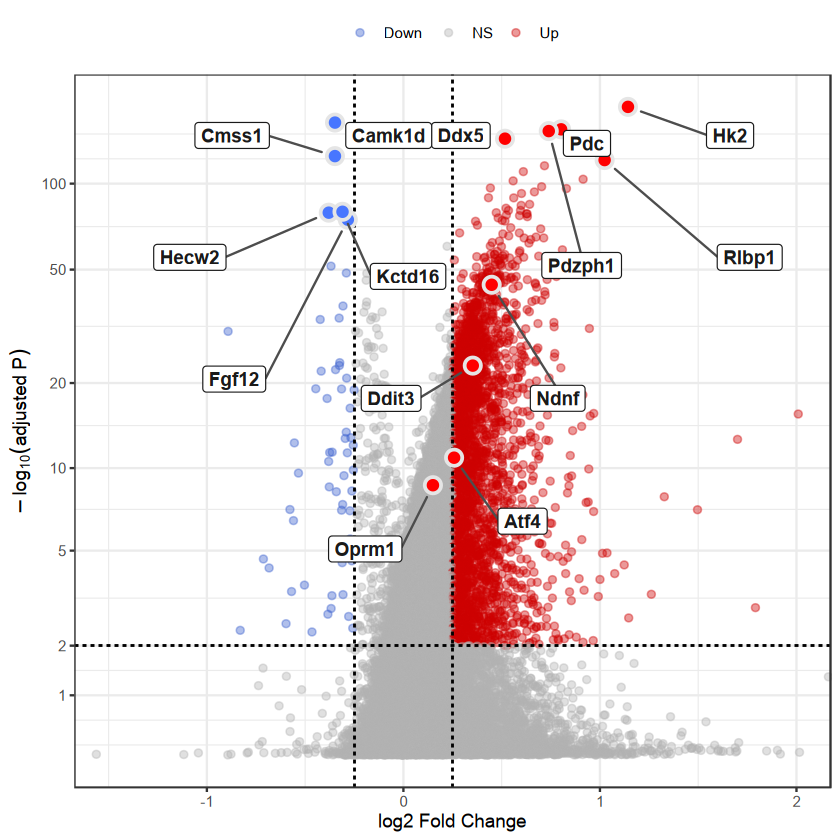

In [6]:
ggplot(df, aes(x = logFC, y = neglog10_padj)) +
  geom_point(aes(color = group), size = 1.6, alpha = 0.4) +
  geom_vline(xintercept = c(-0.25, 0.25),
             color = "black", linetype = "dashed", linewidth = 0.6) +
  geom_hline(yintercept = -log10(0.01),
             color = "black", linetype = "dashed", linewidth = 0.6) +
  geom_point(
    data = df_up, aes(x = logFC, y = neglog10_padj), shape  = 21, fill   = "red1", color  = "grey90", size   = 3.5, stroke = 1.2) +
  geom_point(
    data = df_down, aes(x = logFC, y = neglog10_padj), shape  = 21, fill   = "royalblue1", color  = "grey90", size   = 3.5, stroke = 1.2) +
  geom_label_repel(aes(label=sign), fontface="bold", color="grey10", box.padding=unit(2, "lines"), point.padding=unit(1, "lines"), segment.colour = "grey30") +
  scale_color_manual(
    values = c(
      "Up"   = "red3",
      "Down" = "royalblue3",
      "NS"   = "grey70"
    )
  ) +
  labs(
    x = "log2 Fold Change",
    y = expression(-log[10]("adjusted P")),
    color = NULL
  ) + 
  scale_y_continuous(
    trans = pseudo_log_trans(base = 10),
    breaks = c(1, 2, 5, 10, 20, 50, 100)
  ) + 
  coord_cartesian(xlim = c(-1.5, 2)) +
  theme_bw() +
  theme(
    legend.position = "top"
  )

In [7]:
df <- df_all[df_all$COH_2w_pvals_adj<1,c('COH_2w_names','COH_2w_logfoldchanges','COH_2w_pvals_adj')]
colnames(df) <- c("gene", "logFC", "padj")

In [8]:
df <- df %>%
  mutate(
    neglog10_padj = -log10(padj),
    group = case_when(
      padj < 0.01 & logFC >= 0.25  ~ "Up",
      padj < 0.01 & logFC <= -0.25 ~ "Down",
      TRUE                        ~ "NS"
    )
  )

In [9]:
anno_up <- c('Ush2a','Gm44196','Dmd','Esrrb','Slc22a29')
anno_down <- c('Malat1','Cmss1','Pde10a','Gm42418','Sltm')
df_up <- df %>% filter(gene %in% anno_up)
df_down <- df %>% filter(gene %in% anno_down)
df$sign <- ifelse(df$gene %in% c(anno_up,anno_down),df$gene,NA)

Warning message:
“Removed 8026 rows containing missing values or values outside the scale range
(`geom_label_repel()`).”


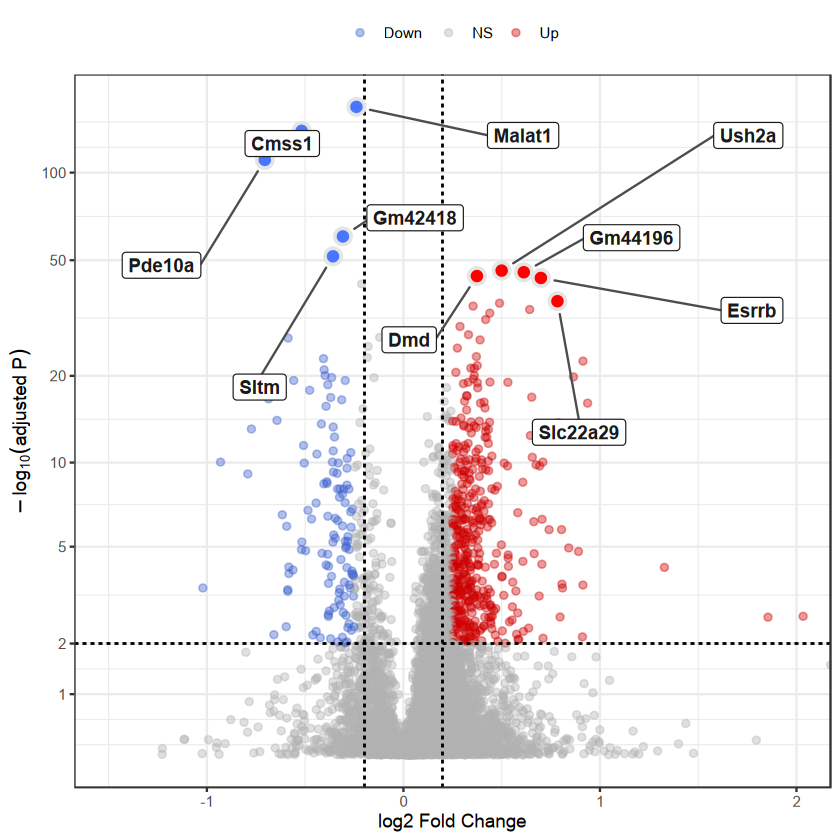

In [10]:
ggplot(df, aes(x = logFC, y = neglog10_padj)) +
  geom_point(aes(color = group), size = 1.6, alpha = 0.4) +
  geom_vline(xintercept = c(-0.2, 0.2),
             color = "black", linetype = "dashed", linewidth = 0.6) +
  geom_hline(yintercept = -log10(0.01),
             color = "black", linetype = "dashed", linewidth = 0.6) +
  geom_point(
    data = df_up, aes(x = logFC, y = neglog10_padj), shape  = 21, fill   = "red1", color  = "grey90", size   = 3.5, stroke = 1.2) +
  geom_point(
    data = df_down, aes(x = logFC, y = neglog10_padj), shape  = 21, fill   = "royalblue1", color  = "grey90", size   = 3.5, stroke = 1.2) +
  geom_label_repel(aes(label=sign), fontface="bold", color="grey10", box.padding=unit(2, "lines"), point.padding=unit(1, "lines"), segment.colour = "grey30", max.overlaps = 100) +
  scale_color_manual(
    values = c(
      "Up"   = "red3",
      "Down" = "royalblue3",
      "NS"   = "grey70"
    )
  ) +
  labs(
    x = "log2 Fold Change",
    y = expression(-log[10]("adjusted P")),
    color = NULL
  ) + 
  scale_y_continuous(
    trans = pseudo_log_trans(base = 10),
    breaks = c(1, 2, 5, 10, 20, 50, 100)
  ) + 
  coord_cartesian(xlim = c(-1.5, 2)) +
  theme_bw() +
  theme(
    legend.position = "top"
  )

In [11]:
df <- df_all[df_all$COH_4w_pvals_adj<1,c('COH_4w_names','COH_4w_logfoldchanges','COH_4w_pvals_adj')]
colnames(df) <- c("gene", "logFC", "padj")

In [12]:
df <- df %>%
  mutate(
    neglog10_padj = -log10(padj),
    group = case_when(
      padj < 0.01 & logFC >= 0.25  ~ "Up",
      padj < 0.01 & logFC <= -0.25 ~ "Down",
      TRUE                        ~ "NS"
    )
  )

In [13]:
anno_up <- c('Folh1','Gm26917','Hk2','Adamtsl1','Nckap5')
anno_down <- c('Cmss1','Snap25','Kctd16','Pde10a','R3hdm2')
df_up <- df %>% filter(gene %in% anno_up)
df_down <- df %>% filter(gene %in% anno_down)
df$sign <- ifelse(df$gene %in% c(anno_up,anno_down),df$gene,NA)

Warning message:
“Removed 15679 rows containing missing values or values outside the scale range
(`geom_label_repel()`).”


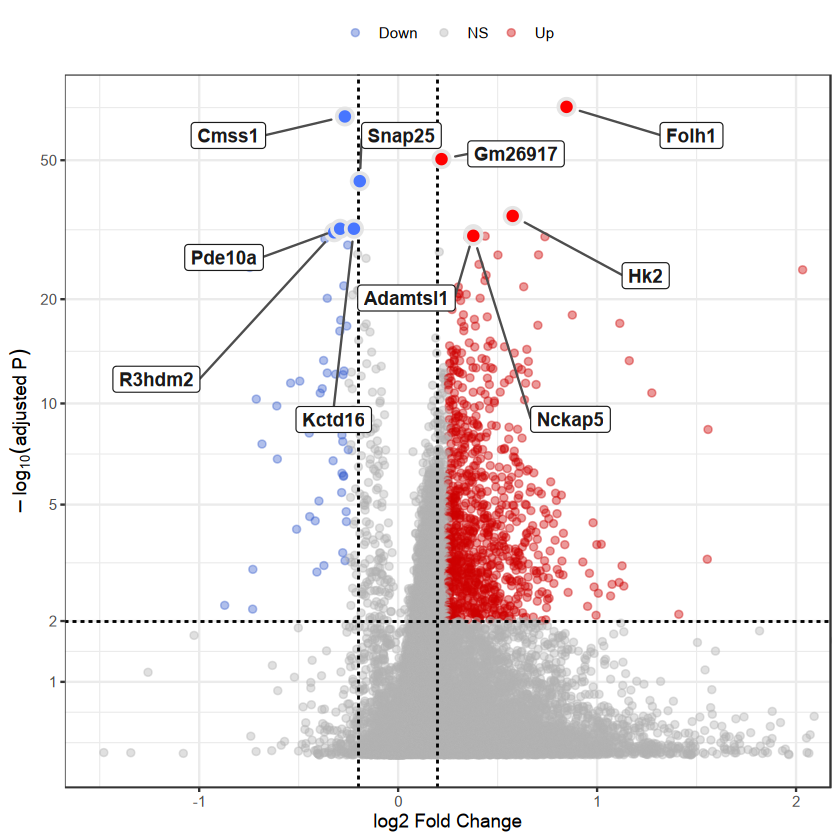

In [14]:
ggplot(df, aes(x = logFC, y = neglog10_padj)) +
  geom_point(aes(color = group), size = 1.6, alpha = 0.4) +
  geom_vline(xintercept = c(-0.2, 0.2),
             color = "black", linetype = "dashed", linewidth = 0.6) +
  geom_hline(yintercept = -log10(0.01),
             color = "black", linetype = "dashed", linewidth = 0.6) +
  geom_point(
    data = df_up, aes(x = logFC, y = neglog10_padj), shape  = 21, fill   = "red1", color  = "grey90", size   = 3.5, stroke = 1.2) +
  geom_point(
    data = df_down, aes(x = logFC, y = neglog10_padj), shape  = 21, fill   = "royalblue1", color  = "grey90", size   = 3.5, stroke = 1.2) +
  geom_label_repel(aes(label=sign), fontface="bold", color="grey10", box.padding=unit(2, "lines"), point.padding=unit(1, "lines"), segment.colour = "grey30", max.overlaps = 100) +
  scale_color_manual(
    values = c(
      "Up"   = "red3",
      "Down" = "royalblue3",
      "NS"   = "grey70"
    )
  ) +
  labs(
    x = "log2 Fold Change",
    y = expression(-log[10]("adjusted P")),
    color = NULL
  ) + 
  scale_y_continuous(
    trans = pseudo_log_trans(base = 10),
    breaks = c(1, 2, 5, 10, 20, 50, 100)
  ) + 
  coord_cartesian(xlim = c(-1.5, 2)) +
  theme_bw() +
  theme(
    legend.position = "top"
  )